In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import torch, glob
import matplotlib.pyplot as plt
import numpy as np
from wassa_plots import plot_SM, plot_results
from wassa_utils import get_best_results
from wassa_training import get_training_parameters, learn_motifs, unsupervised_learning
from wassa_metrics import get_similarity, torch_cdf_loss
from wassa import WassA
from dataset_generation import kfold_dataset, generate_dataset, get_dataset_parameters

## Get statistics from real data

In [101]:
dataset_path = '../allen_data_by_image/'
dataset_name = 'bin_tensor_session_02_NS'
data = torch.load(dataset_path+dataset_name+'.pt', weights_only = True)

In [102]:
device = 'cpu'

In [103]:
def make_allen_dataset(data, number_samples_per_image=10, number_folds=5, device='cpu'):
    data = data.to(torch.float32).to(device)
    number_samples, number_neurons, number_timesteps = data.shape
    number_images = number_samples//number_samples_per_image
    all_trainsets, all_testsets, all_othersets = [], [], []
    for image in range(number_images):
        trainsets, testsets, indices = kfold_dataset(data[image*number_samples_per_image:(image+1)*number_samples_per_image],k=number_folds)
        other_testsets = []
        for i in range(len(testsets)):
            image_numbers = torch.randint(number_images,(testsets[0].shape[0],))
            while image in image_numbers:
                image_numbers = torch.randint(number_images,(testsets[0].shape[0],))
            sample_numbers = torch.randint(number_samples_per_image,(testsets[0].shape[0],))
            other_testsets.append(data[image_numbers*number_samples_per_image+sample_numbers])
        all_trainsets += trainsets
        all_testsets += testsets
        all_othersets += other_testsets
    return all_trainsets, all_testsets, all_othersets

In [104]:
from wassa_metrics import WassDist, kernels_diff
from wassa_utils import correlation_kernels
from tqdm.notebook import tqdm 

def reconstruction_comparison(dataset_name,data,training_parameters,metric_names,frs=False,saving_path = 'results/allen_better_norm',device='cpu'):

    mse_loss = torch.nn.MSELoss()
    emd_loss = WassDist(zeros='same',normalize=training_parameters['normalize_input'])
    
    all_trainsets, all_testsets, all_othersets = make_allen_dataset(data,device=device)
    results = torch.zeros([len(all_trainsets),7,2])
    if frs==False:
        all_weights = torch.zeros([len(all_trainsets),training_parameters['kernel_size'][0],training_parameters['kernel_size'][1],training_parameters['kernel_size'][2]])
    elif frs=='pop':
        all_weights = torch.zeros([len(all_trainsets),training_parameters['kernel_size'][0],1,training_parameters['kernel_size'][2]])
    else:
        all_weights = torch.zeros([len(all_trainsets),training_parameters['kernel_size'][0],training_parameters['kernel_size'][1],1])
        
    for ind in tqdm(range(len(all_trainsets))):
        if frs==False:
            training_set, testing_set, othersets = all_trainsets[ind], all_testsets[ind], all_othersets[ind]
        elif frs=='pop':
            training_set, testing_set, othersets = all_trainsets[ind].mean(dim=1).unsqueeze(1), all_testsets[ind].mean(dim=1).unsqueeze(1), all_othersets[ind].mean(dim=1).unsqueeze(1)
        else:
            training_set, testing_set, othersets = all_trainsets[ind].mean(dim=-1).unsqueeze(-1), all_testsets[ind].mean(dim=-1).unsqueeze(-1), all_othersets[ind].mean(dim=-1).unsqueeze(-1)
            
        num_samples, num_neurons, num_timesteps = training_set.shape
        training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
        model = WassA(training_parameters,device=device)
        model_name = saving_path+dataset_name+str(ind)+get_training_parameters(training_parameters)
        model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None,verbose=False)
        if training_parameters['normalize_input']:
            othersets = torch.nn.functional.normalize(othersets, p=1, dim=2)
            testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
        factors_other, otherset_hat = model(othersets)
        factors_testing, testingset_hat = model(testing_set)
        #if training_parameters['normalize_input']:
        #    otherset_hat = torch.nn.functional.normalize(otherset_hat, p=1, dim=2)
        #    testingset_hat = torch.nn.functional.normalize(testingset_hat, p=1, dim=2)
        results[ind,0,0] = mse_loss(testingset_hat,testing_set).detach()
        results[ind,0,1] = mse_loss(otherset_hat,othersets).detach()
        results[ind,1,1] = emd_loss(otherset_hat,othersets).detach()
        results[ind,1,0] = emd_loss(testingset_hat,testing_set).detach()
        results[ind,2,1] = (1-torch.var(othersets-otherset_hat)/torch.var(othersets)).nanmean().detach()
        results[ind,2,0] = (1-torch.var(testing_set-testingset_hat)/torch.var(testing_set)).nanmean().detach();
        correlation_kernel_testset, mse_kernel_testset, emd_kernel_testset = 0, 0, 0
        correlation_kernel_otherset, mse_kernel_otherset, emd_kernel_otherset = 0, 0, 0
        weights = model.weights.data.detach()
        #weights[weights.std(dim=-1)<8e-5] = 0
        #print(weights.std(dim=-1))
        for i in range(othersets.shape[0]):
            input_spikes, input_spikes_others = testing_set[i].unsqueeze(0).detach(), othersets[i].unsqueeze(0).detach()
            correlation_kernel_testset += correlation_kernels(input_spikes, weights)
            correlation_kernel_otherset += correlation_kernels(input_spikes_others, weights)
            mse_kernel_testset += kernels_diff(input_spikes, weights, 'mse')
            mse_kernel_otherset += kernels_diff(input_spikes_others, weights, 'mse')
            emd_kernel_testset += kernels_diff(input_spikes, weights, 'emd')
            emd_kernel_otherset += kernels_diff(input_spikes_others, weights, 'emd')
        results[ind,3,0] = correlation_kernel_testset/othersets.shape[0]
        results[ind,3,1] = correlation_kernel_otherset/othersets.shape[0]
        results[ind,4,0] = mse_kernel_testset/othersets.shape[0]
        results[ind,4,1] = mse_kernel_otherset/othersets.shape[0]
        results[ind,5,0] = emd_kernel_testset/othersets.shape[0]
        results[ind,5,1] = emd_kernel_otherset/othersets.shape[0]
        results[ind,6,0] = factors_testing.detach().mean()
        results[ind,6,1] = factors_other.detach().mean()
        all_weights[ind] = weights#model.weights.data.detach()
        
    return results, all_weights

In [105]:
training_parameters_emd = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [106]:
number_samples = 10
number_folds = 5
saving_path = 'results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

results/wassa_allen_bin_tensor_session_02_NS1021318250emdemd likeFalse220000.01None0NoneFalseflatTrue00


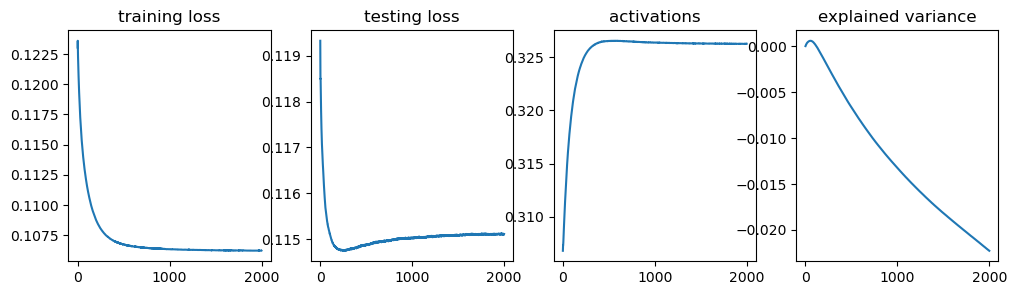

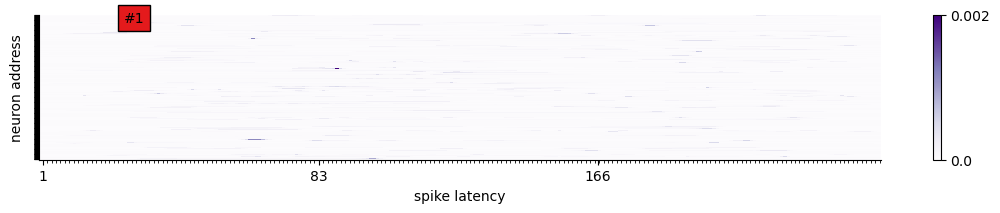

In [107]:
online_plots = False
image = 2
trainsets, testsets, indices = kfold_dataset(data[image*number_samples:(image+1)*number_samples].to(torch.float32).to(device),k=number_folds)
k, iteration = 0, 1
training_set, testing_set = trainsets[k], testsets[k]
model = WassA(training_parameters_emd,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_emd)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters_emd,model_name, metric_names,None,online_plots=online_plots)
plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

In [108]:
results_emd, weights_emd = reconstruction_comparison(dataset_name,data,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/100 [00:00<?, ?it/s]

In [109]:
weights_emd.shape

torch.Size([100, 1, 318, 250])

In [110]:
weights_emd.std(dim=-1)[0,0]>8e-5

tensor([False, False, False, False, False, False, False,  True, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

In [82]:
example_weights_emd = weights_emd[0,0]
significative_std_emd = example_weights_emd[example_weights_emd.std(dim=-1)>1e-6]
sorted_weights_emd_emd = example_weights_emd[example_weights_emd.argmax(dim=1).argsort()]
sorted_significative_emd = significative_std_emd[significative_std_emd.argmax(dim=1).argsort()]

In [83]:
example_weights_mse = weights_mse[0,0]
significative_std_mse = example_weights_mse[example_weights_mse.std(dim=-1)>1e-6]
sorted_weights_mse_mse = example_weights_mse[example_weights_mse.argmax(dim=1).argsort()]
sorted_significative_mse = significative_std_mse[significative_std_mse.argmax(dim=1).argsort()]

In [84]:
sorted_weights_mse_emd = example_weights_mse[example_weights_emd.argmax(dim=1).argsort()]
sorted_weights_emd_mse = example_weights_emd[example_weights_mse.argmax(dim=1).argsort()]

Text(0.5, 0, 'time (in ms)')

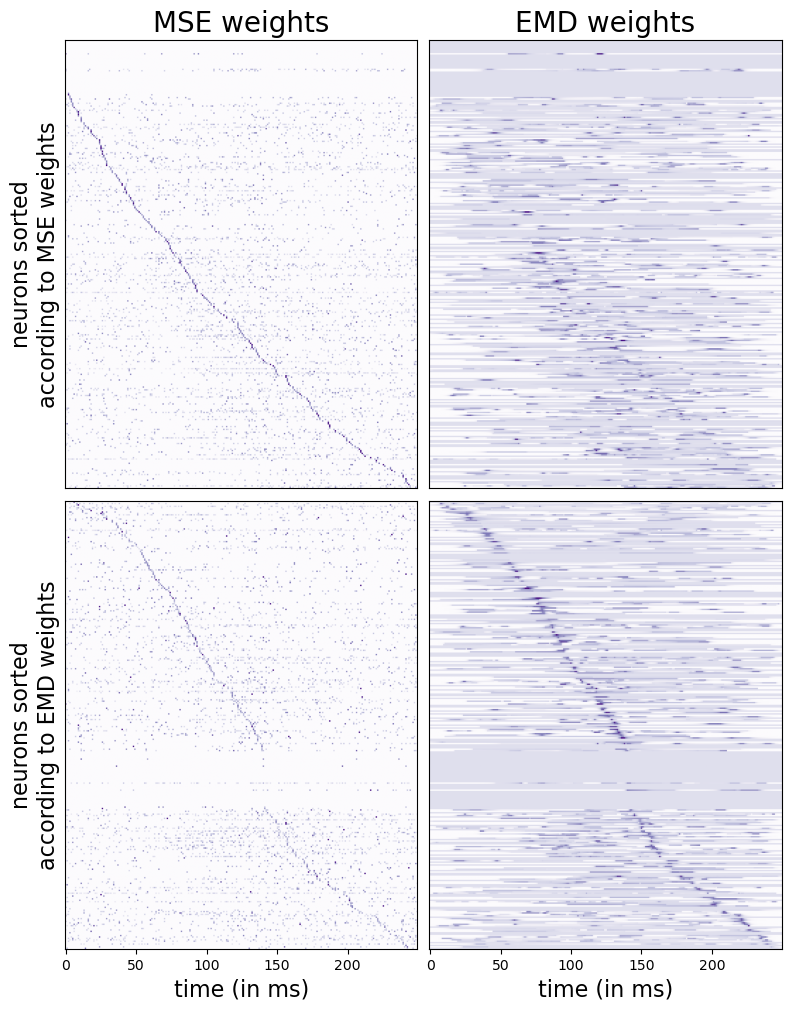

In [97]:
cmap = 'Purples'
coef = .4
fig, ax = plt.subplots(2,2,figsize=(7.8,10),constrained_layout = True)
ax[0,0].imshow(sorted_weights_mse_mse**coef,cmap=cmap)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
ax[0,0].set_title('MSE weights',fontsize=20)
ax[0,0].set_ylabel('neurons sorted\naccording to MSE weights',fontsize=16)
ax[0,1].imshow(sorted_weights_emd_mse**coef,cmap=cmap)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[0,1].set_title('EMD weights',fontsize=20)
ax[1,0].imshow(sorted_weights_mse_emd**coef,cmap=cmap)
ax[1,0].set_yticks([])
ax[1,0].set_ylabel('neurons sorted\naccording to EMD weights',fontsize=16)
ax[1,1].imshow(sorted_weights_emd_emd**coef,cmap=cmap)
ax[1,1].set_yticks([])
ax[1,0].set_xlabel('time (in ms)',fontsize=16)
ax[1,1].set_xlabel('time (in ms)',fontsize=16)

In [98]:
fig.savefig('../figures/results_allen_example.pdf', bbox_inches = 'tight')

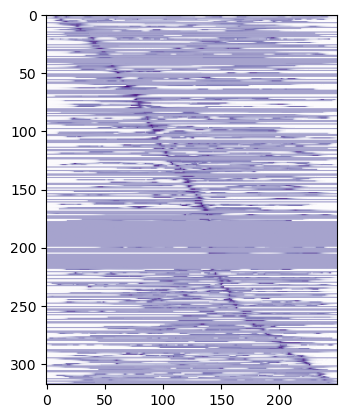

In [73]:
plt.imshow(sorted_weights_emd**.2,cmap='Purples')

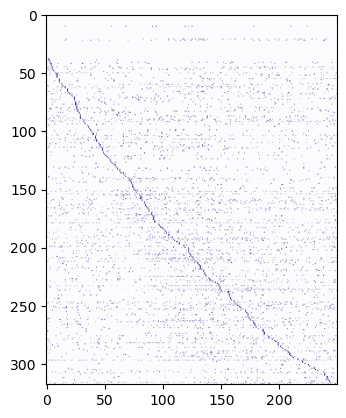

In [81]:
plt.imshow(sorted_weights_mse**.3,cmap='Purples')

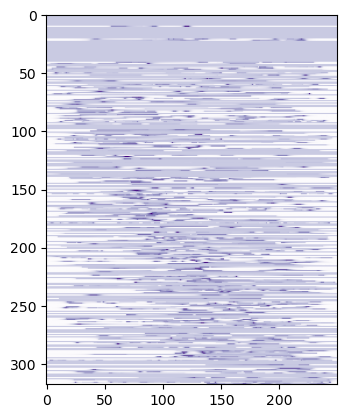

In [80]:
plt.imshow(sorted_weights_emd**.3,cmap='Purples')

In [18]:
std_weights.max()

tensor(0.0002)

In [ ]:
np.arange(0,std_weights.max(),std_weights.max()*1e-2)

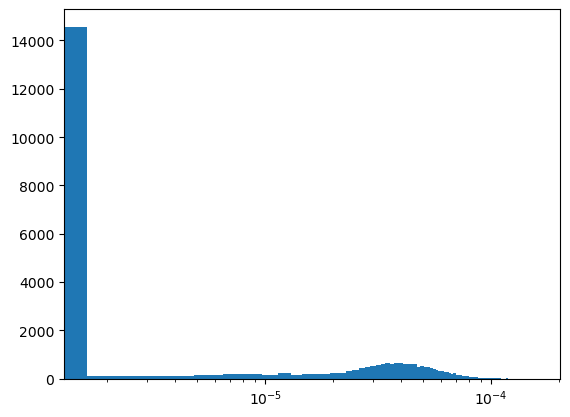

In [19]:
plt.hist(std_weights.flatten(), bins = np.arange(0,std_weights.max(),std_weights.max()*1e-2))
plt.xscale('log')

In [ ]:
plt.scatter(torch.arange(std_weights.shape[1]).unsqueeze(0).repeat(std_weights.shape[0],1),std_weights)
plt.yscale('log')

In [41]:
training_parameters_mse = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

  0%|          | 0/2000 [00:00<?, ?it/s]

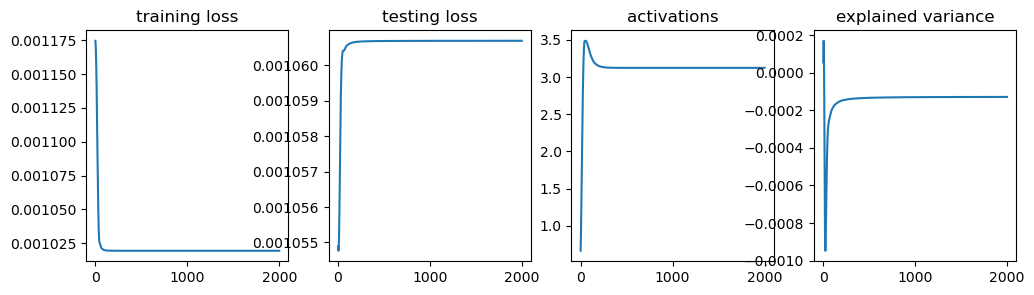

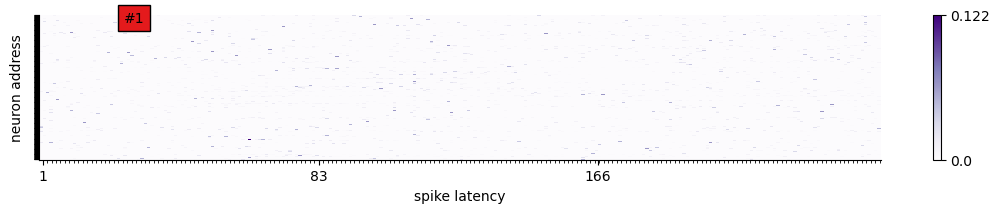

In [12]:
model = WassA(training_parameters_mse,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_mse)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters_mse,model_name,metric_names,None,online_plots=online_plots)
plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

In [42]:
results_mse, weights_mse = reconstruction_comparison(dataset_name,data, training_parameters_mse,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/100 [00:00<?, ?it/s]

In [14]:
training_parameters_frs = {
    'kernel_size' : (1, data.shape[1], 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

  0%|          | 0/2000 [00:00<?, ?it/s]

/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/matplotlib/ticker.py:2976: RuntimeWarning: divide by zero encountered in scalar divide
  minorstep = majorstep / ndivs
/home/antoine/miniconda3/envs/wassa/lib/python3.12/site-packages/matplotlib/ticker.py:2982: RuntimeWarning: invalid value encountered in multiply
  locs = (np.arange(tmin, tmax) * minorstep) + t0


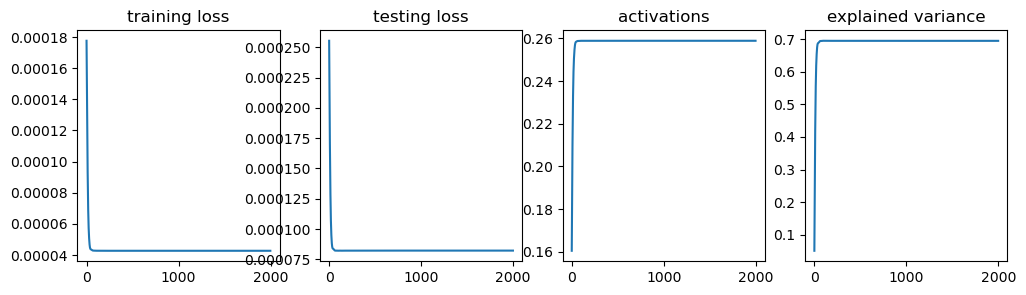

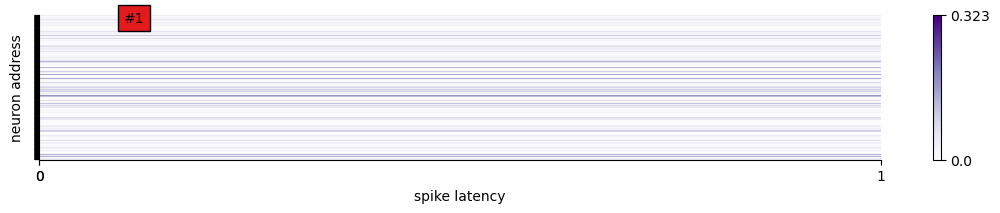

In [15]:
model = WassA(training_parameters_frs,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_frs)
model, training_metrics, _ = learn_motifs(model,training_set.mean(dim=-1).unsqueeze(-1),testing_set.mean(dim=-1).unsqueeze(-1),training_parameters_frs,model_name,metric_names,None,online_plots=online_plots)
plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

In [16]:
results_frs, weights_mse_frs = reconstruction_comparison(dataset_name,data,training_parameters_frs,metric_names,frs=True,saving_path=saving_path,device=device)

  0%|          | 0/100 [00:00<?, ?it/s]

In [17]:
training_parameters_pop = {
    'kernel_size' : (1, 1, data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [18]:
model = WassA(training_parameters_pop,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_pop)
model, training_metrics, _ = learn_motifs(model,training_set.mean(dim=1).unsqueeze(1),testing_set.mean(dim=1).unsqueeze(1),training_parameters_pop,model_name,metric_names,None,online_plots=online_plots)
#plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
plt.imshow(model.weights.data.detach()[0],aspect='auto')

In [19]:
results_pop, weights_mse_pop = reconstruction_comparison(dataset_name,data,training_parameters_pop,metric_names,frs='pop',saving_path=saving_path,device=device)

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_3137882/1141627368.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax[i,2].set_ylim([min(mean_frs)-2*max(std_frs), max(mean_frs)+2*max(std_frs)])


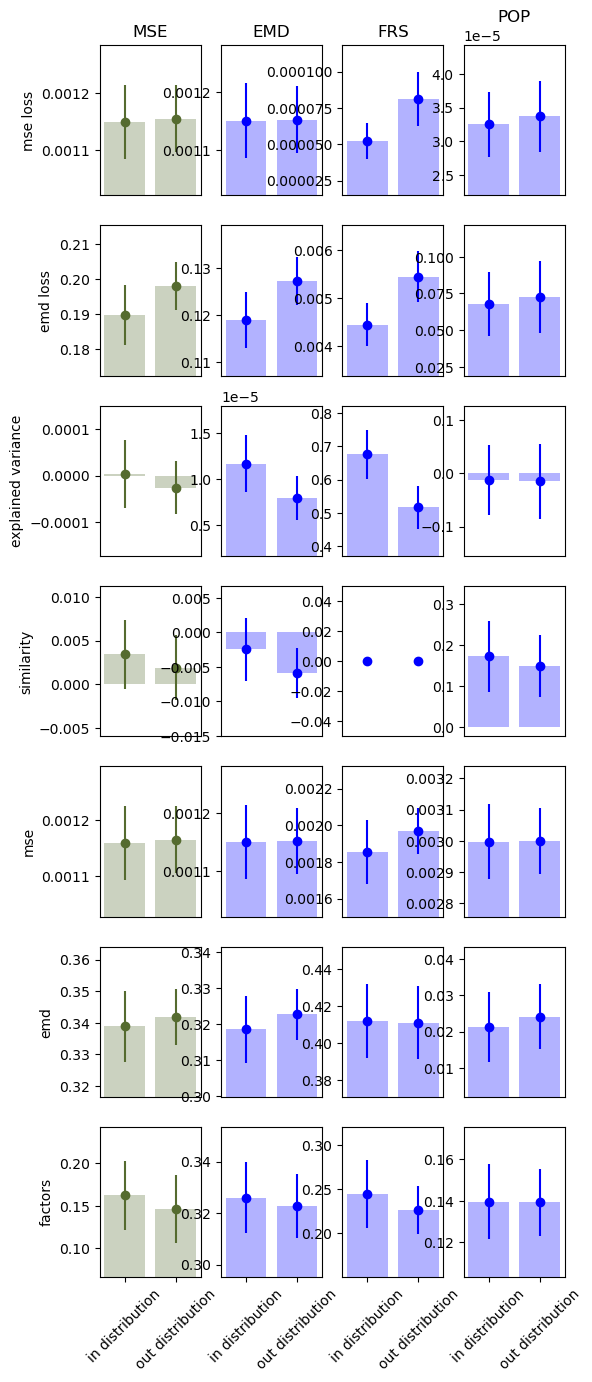

In [20]:
all_metrics = ['mse loss', 'emd loss', 'explained variance', 'similarity', 'mse', 'emd', 'factors']
fig, ax = plt.subplots(results_emd.shape[1],4,figsize=(6,16))
for i in range(results_emd.shape[1]):
    for j in range(2):
        mean_mse, std_mse = results_mse[:,i].mean(dim=0), results_mse[:,i].std(dim=0)
        mean_emd, std_emd = results_emd[:,i].mean(dim=0), results_emd[:,i].std(dim=0)
        mean_frs, std_frs = results_frs[:,i].mean(dim=0), results_frs[:,i].std(dim=0)
        mean_pop, std_pop = results_pop[:,i].mean(dim=0), results_pop[:,i].std(dim=0)
        ax[i,0].bar(j,mean_mse[j],color='darkolivegreen',alpha=.3)
        ax[i,0].errorbar(j, mean_mse[j], yerr=std_mse[j], fmt='-o', color='darkolivegreen')
        ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[i,0].set_xticks([])
        ax[i,0].set_ylabel(all_metrics[i])

        ax[i,1].bar(j,mean_emd[j],color='blue',alpha=.3)
        ax[i,1].errorbar(j, mean_emd[j], yerr=std_emd[j], fmt='-o', color='blue')
        ax[i,1].set_ylim([min(mean_emd)-2*max(std_emd), max(mean_emd)+2*max(std_emd)])
        ax[i,1].set_xticks([])
        
        ax[i,2].bar(j,mean_frs[j],color='blue',alpha=.3)
        ax[i,2].errorbar(j, mean_frs[j], yerr=std_frs[j], fmt='-o', color='blue')
        ax[i,2].set_ylim([min(mean_frs)-2*max(std_frs), max(mean_frs)+2*max(std_frs)])
        ax[i,2].set_xticks([])

        ax[i,3].bar(j,mean_pop[j],color='blue',alpha=.3)
        ax[i,3].errorbar(j, mean_pop[j], yerr=std_pop[j], fmt='-o', color='blue')
        ax[i,3].set_ylim([min(mean_pop)-2*max(std_pop), max(mean_pop)+2*max(std_pop)])
        ax[i,3].set_xticks([])


ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[0,3].set_title('POP')
ax[i,0].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
ax[i,1].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
ax[i,2].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
ax[i,3].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)

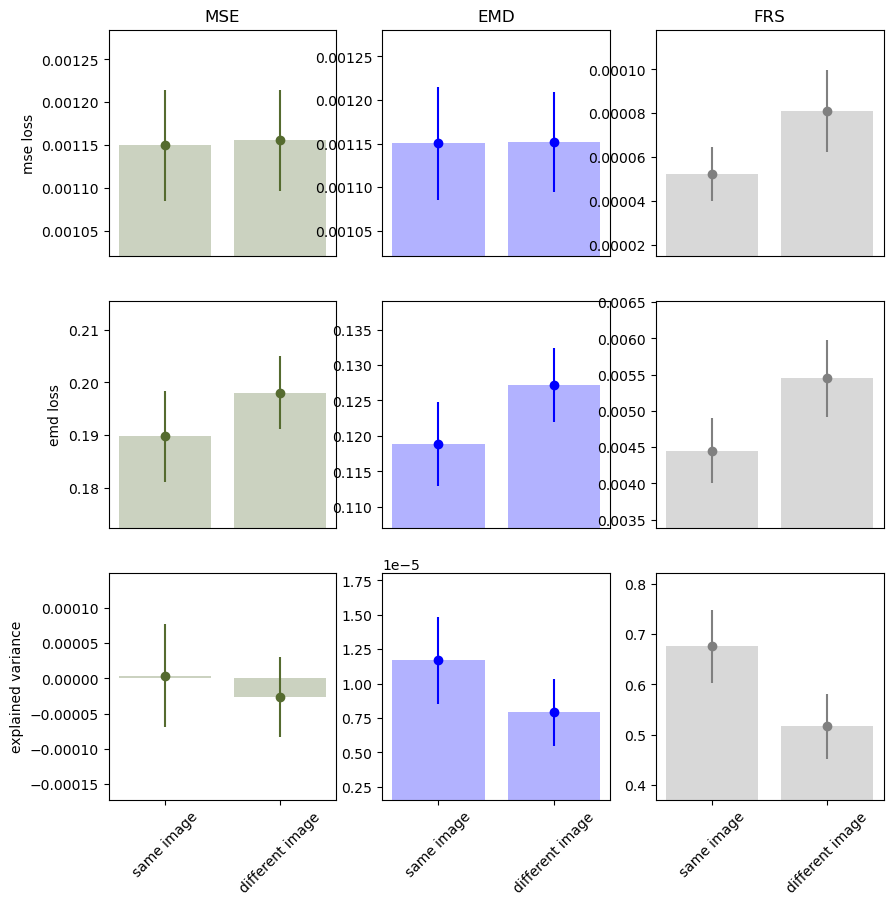

In [26]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):
    for j in range(2):
        mean_mse, std_mse = results_mse[:,i].mean(dim=0), results_mse[:,i].std(dim=0)
        mean_emd, std_emd = results_emd[:,i].mean(dim=0), results_emd[:,i].std(dim=0)
        mean_frs, std_frs = results_frs[:,i].mean(dim=0), results_frs[:,i].std(dim=0)
        mean_pop, std_pop = results_pop[:,i].mean(dim=0), results_pop[:,i].std(dim=0)
        ax[i,0].bar(j,mean_mse[j],color='darkolivegreen',alpha=.3)
        ax[i,0].errorbar(j, mean_mse[j], yerr=std_mse[j], fmt='-o', color='darkolivegreen')
        ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[i,0].set_xticks([])
        ax[i,0].set_ylabel(all_metrics[i])

        ax[i,1].bar(j,mean_emd[j],color='blue',alpha=.3)
        ax[i,1].errorbar(j, mean_emd[j], yerr=std_emd[j], fmt='-o', color='blue')
        ax[i,1].set_ylim([min(mean_emd)-2*max(std_emd), max(mean_emd)+2*max(std_emd)])
        ax[i,1].set_xticks([])
        
        ax[i,2].bar(j,mean_frs[j],color='grey',alpha=.3)
        ax[i,2].errorbar(j, mean_frs[j], yerr=std_frs[j], fmt='-o', color='grey')
        ax[i,2].set_ylim([min(mean_frs)-2*max(std_frs), max(mean_frs)+2*max(std_frs)])
        ax[i,2].set_xticks([])


ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[i,0].set_xticks([0,1], ['same image', 'different image'], rotation=45)
ax[i,1].set_xticks([0,1], ['same image', 'different image'], rotation=45)
ax[i,2].set_xticks([0,1], ['same image', 'different image'], rotation=45)

In [28]:
fig.tight_layout()
fig.savefig('../figures/results_allen.pdf', bbox_inches = 'tight')

In [22]:
training_parameters_emd_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']
model = WassA(training_parameters_emd_nonorm,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_emd_nonorm)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters_emd_nonorm,model_name, metric_names,None,online_plots=online_plots)
plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

In [ ]:
metric_names = ['training loss', 'testing loss', 'explained variance']
results_emd_nonorm, weights_emd_nornorm = reconstruction_comparison(dataset_name,data,training_parameters_emd_nonorm,metric_names,saving_path=saving_path,device=device)

In [ ]:
training_parameters_mse_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']
model = WassA(training_parameters_mse_nonorm,device=device)
model_name = saving_path+dataset_name+str(iteration)+str(k)+str(image)+get_training_parameters(training_parameters_mse_nonorm)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters_mse_nonorm,model_name, metric_names,None,online_plots=online_plots)
plot_results(training_metrics, metric_names, model, testing_set, spike_times = None)

In [ ]:
metric_names = ['training loss', 'testing loss', 'explained variance']
results_mse_nonorm, weights_mse_nonorm = reconstruction_comparison(dataset_name,data,training_parameters_mse_nonorm,metric_names,saving_path=saving_path,device=device)

In [ ]:
all_metrics = ['mse loss', 'emd loss', 'explained variance', 'similarity', 'mse', 'emd', 'factors']
fig, ax = plt.subplots(2,results_emd.shape[1],figsize=(16,6))
for i in range(results_emd.shape[1]):
    for j in range(2):
        mean_mse, std_mse = results_mse_nonorm[:,i].mean(dim=0), results_mse_nonorm[:,i].std(dim=0)
        mean_emd, std_emd = results_emd_nonorm[:,i].mean(dim=0), results_emd_nonorm[:,i].std(dim=0)
        ax[0,i].bar(j,mean_mse[j],color='darkolivegreen',alpha=.3)
        ax[0,i].errorbar(j, mean_mse[j], yerr=std_mse[j], fmt='-o', color='darkolivegreen')
        ax[0,i].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[0,i].set_title(all_metrics[i])
        ax[0,0].set_ylabel('MSE')
        ax[0,i].set_xticks([])
        #ax[0,i].set_yscale('log', base=10)
        ax[1,i].bar(j,mean_emd[j],color='blue',alpha=.3)
        ax[1,i].errorbar(j, mean_emd[j], yerr=std_emd[j], fmt='-o', color='blue')
        ax[1,i].set_ylim([min(mean_emd)-2*max(std_emd), max(mean_emd)+2*max(std_emd)])
        ax[1,i].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
        ax[1,0].set_ylabel('EMD')

In [ ]:
similarity_matrix_emd = torch.corrcoef(weights_emd.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_emd-torch.eye(similarity_matrix_emd.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_emd.div(torch.norm(weights_emd, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_mse = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [ ]:
weights_mse = extract_weights(data, 5, training_parameters_mse, device)

In [ ]:
similarity_matrix_mse = torch.corrcoef(weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_mse-torch.eye(similarity_matrix_mse.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_mse.div(torch.norm(weights_mse, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_emd_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 1,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
weights_emd_nonorm = extract_weights(data, 5, training_parameters_emd_nonorm, device)

In [ ]:
similarity_matrix_emd_nonorm = torch.corrcoef(weights_emd_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_emd_nonorm-torch.eye(similarity_matrix_emd_nonorm.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_emd_nonorm.div(torch.norm(weights_mse, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_mse_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
weights_mse_nonorm = extract_weights(data, 5, training_parameters_mse_nonorm, device)

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(weights_mse_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_nonorm-torch.eye(similarity_matrix_nonorm.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_mse_nonorm.div(torch.norm(weights_mse_nonorm, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
plt.imshow(similarity_matrix_mse-similarity_matrix_emd);
plt.colorbar();

In [ ]:
plt.imshow(similarity_matrix_mse-similarity_matrix_nonorm)
plt.colorbar()

1. Do the training on different images for the same animal. (no fold)
2. Check how similar are the patterns for one image to another. Can we decode images with one temporal sequence ? Or this sequence is shared for every stimuli (does not mean there is no sequence for each stimuli but that the response is dominated by this main one)
3. - If yes: check which metric helps to decode better (if EMD -> end, if MSE not normalized input then precise sequences help to decode better)
   - If not: can we add another kernel on top of this to see wether there is another sequence ? (can be infinite...)

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(torch.vstack([weights_mse_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1),weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1)]))
plt.imshow(similarity_matrix_nonorm-torch.eye(similarity_matrix_nonorm.shape[0]))
plt.colorbar()

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(torch.vstack([weights_emd.flatten(end_dim=1).squeeze(1).flatten(start_dim=1),weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1)]))
plt.imshow(similarity_matrix_nonorm)
plt.colorbar()